---
date: "2026-08-07"
date-modified: last-modified
format:
  html:
    toc: true
---


# Single-Period Investment Model

The **single-period investment model** forms the foundational building block of mathematical finance and financial engineering. It provides a formal, quantitative framework for evaluating financial assets, returns, and risks across a single discrete time interval.

Financial modeling fundamental principles revolve around two primary real-world phenomena:

1. **Time Value of Money**: Capital has a time cost. A deterministic dollar received today at time $t=0$ is worth more than a dollar received at a future time $t=1$, because money available today can be invested to earn a risk-free return.
2. **Uncertainty and Risk**: Future asset values at time $t=1$ are unknown at time $t=0$. Therefore, future financial payoffs must be modeled as [random variables](random-variables.ipynb) on a defined [probability space](sample-space.ipynb).

::: {#def-single-period-economy}
## Single-Period Economy
A **single-period economy** is defined over a discrete time domain consisting of exactly two time points:
$$
T = \{0, 1\}
$$

- **Time $t=0$ (Present / Decision Date):** All current asset prices, interest rates, and model parameters are known deterministically. Portfolios are constructed at $t=0$.
- **Time $t=1$ (Future / Payoff Date):** Economic states are revealed, uncertainty is resolved, and asset payoffs or dividends are realized.
:::

### 1.1\. Time Value of Money & Present Value

To compare monetary amounts occurring at different points in time, we discount future cash flows back to the present.

::: {#def-present-value}
## Present Value
If an investment yields a guaranteed (or expected) cash payoff $x$ at time $t=1$, its **Present Value** $\text{PV}(x)$ at time $t=0$ under a risk-free interest rate $R_{rf}$ is defined as:
$$
\text{PV}(x) = \frac{x}{1 + R_{rf}}
$$
where $1 + R_{rf}$ is the gross risk-free discount rate.
:::

::: {.callout-tip collapse="true"}
## Derivation of Present Value Formula
Let $P$ be the capital invested at time $t=0$ in a risk-free bank account paying simple interest $R_{rf}$.
At time $t=1$, the total accumulated value is:
$$
V(1) = P \cdot (1 + R_{rf})
$$
To achieve a target cash payoff $V(1) = x$ at time $t=1$, the required initial capital $P = \text{PV}(x)$ at time $t=0$ must satisfy:
$$
\begin{aligned}
\text{PV}(x) \cdot (1 + R_{rf}) &= x \\
\implies \text{PV}(x) &= \frac{x}{1 + R_{rf}} \quad \blacksquare
\end{aligned}
$$
:::

::: {.callout-note}
## Intuition: Time Value of Money
Because of the risk-free rate $R_{rf} > 0$, receiving $\$100$ today is strictly preferable to receiving $\$100$ one year from now. By depositing $\$100$ today, you would hold $\$100(1 + R_{rf})$ in one year. Discounting translates future payoffs into equivalent current capital.
:::


## 2\. One-Period Return Dynamics

Let $S(0) > 0$ denote the known price of a stock at time $t=0$, and let $S(1)$ denote the stock price at time $t=1$, which is a non-negative [random variable](random-variables.ipynb).

### 2.1\. Simple Net Return and Expected Return

::: {#def-simple-net-return}
## Simple Net Return
The **one-period simple net return** $R$ of an asset purchased at time $t=0$ and held until time $t=1$ is defined as the relative capital gain:
$$
R = \frac{S(1) - S(0)}{S(0)}
$$
:::

The **gross return** is defined as $1 + R = \frac{S(1)}{S(0)}$.

::: {#def-expected-return}
## Expected Return
Taking the [Expected Value](expectation.ipynb) of the simple net return $R$, the **expected return** $\mu_R = E[R]$ is given by:
$$
\mu_R = E[R] = \frac{E[S(1)] - S(0)}{S(0)} = \frac{\mu_S - S(0)}{S(0)}
$$
where $\mu_S = E[S(1)]$ is the expected terminal price.
:::

Using the definition of net return, the terminal stock price $S(1)$ and its expected value $E[S(1)]$ can be expressed dynamically in terms of $R$:
$$
S(1) = S(0)(1 + R)
$$
$$
E[S(1)] = S(0)(1 + \mu_R)
$$

::: {.callout-warning}
## Warning: Limited Liability and Return Lower Bound
Under standard corporate finance principles, common stocks feature limited liability, meaning $S(1) \ge 0$ with probability $1$. This imposes a strict lower bound on the simple net return:
$$
S(1) \ge 0 \implies S(0)(1 + R) \ge 0 \implies 1 + R \ge 0 \implies R \ge -1
$$
An investor can lose at most $100\%$ of their initial investment ($R = -1$).
:::

### 2.2\. Dividend-Adjusted Return

If an asset pays cash dividends during the holding period, the return must incorporate total economic cash flow.

::: {#def-dividend-adjusted-return}
## Dividend-Adjusted Net Return
Let $\text{Div}(1) \ge 0$ be the dividend paid per share at time $t=1$ (which is in general a [random variable](random-variables.ipynb)). The **dividend-adjusted net return** $R_{div}$ is:
$$
R_{div} = \frac{S(1) + \text{Div}(1) - S(0)}{S(0)}
$$
:::

### 2.3\. Risk-Free Asset and Discount Factor

::: {#def-risk-free-bond}
## Risk-Free Asset (Zero-Coupon Bond)
A **risk-free asset** (or risk-free bond) is a security whose payoff at time $t=1$ is guaranteed and deterministic.
Consider a zero-coupon bond paying $B(1) = 1$ unit of currency at $t=1$. Let $B(0)$ denote its price at $t=0$.
The risk-free rate of return $R_{rf}$ satisfies:
$$
R_{rf} = \frac{1 - B(0)}{B(0)} \implies B(0) = \frac{1}{1 + R_{rf}}
$$
The price $B(0)$ is called the **discount factor**.
:::

::: {.callout-tip collapse="true"}
## Derivation of Bond Price and Discount Factor Relationship
By definition of simple return applied to the bond price $B(0)$ and deterministic terminal payoff $B(1) = 1$:
$$
\begin{aligned}
R_{rf} &= \frac{B(1) - B(0)}{B(0)} = \frac{1 - B(0)}{B(0)} \\
\implies R_{rf} \cdot B(0) &= 1 - B(0) \\
\implies B(0)(1 + R_{rf}) &= 1 \\
\implies B(0) &= \frac{1}{1 + R_{rf}} \quad \blacksquare
\end{aligned}
$$
:::


## 3\. Probabilistic Framework

To analyze portfolio optimization and asset pricing under risk, we formalize the market model using probability theory on an underlying [probability space](sample-space.ipynb).

### 3.1\. Discrete State Space $\Omega$

Consider a finite set of possible economic scenarios or states of the world at time $t=1$.

::: {#def-discrete-market-space}
## Discrete Market Probability Space
Let $(\Omega, \mathcal{F}, \mathbb{P})$ be a finite probability space where:

1. **Sample Space:** $\Omega = \{\omega_1, \omega_2, \dots, \omega_N\}$ represents $N$ mutually exclusive states of the economy at $t=1$.
2. **$\sigma$-Algebra:** $\mathcal{F} = 2^\Omega$ (the power set of $\Omega$).
3. **Probability Measure:** $\mathbb{P}(\{\omega_i\}) = p_i$, satisfying $p_i > 0$ for all $i \in \{1, \dots, N\}$ and $\sum_{i=1}^N p_i = 1$.
:::

In this discrete setup, the initial stock price $S(0)$ is a constant scalar, while the terminal stock price $S(1, \cdot)$ is a random variable mapping $\Omega \to \mathbb{R}_{\ge 0}$:
$$
S(1, \omega_i) = S_i, \quad \text{for state } \omega_i
$$

::: {#def-discrete-moments}
## Discrete Expected Price and Price Variance
Under the discrete probability measure $\mathbb{P}$, the [Expected Value](expectation.ipynb) and [Variance](variance.ipynb) of the terminal stock price $S(1)$ are:
$$
E[S(1)] = \sum_{i=1}^N S(1, \omega_i) \cdot p_i
$$
$$
\text{Var}[S(1)] = \sum_{i=1}^N \left[ S(1, \omega_i) - E[S(1)] \right]^2 \cdot p_i
$$
:::

::: {.callout-note}
## Intuition: Discrete Scenario Tree
In a two-state binomial model ($N=2$), $\Omega = \{\omega_{\text{up}}, \omega_{\text{down}}\}$. The stock price either moves up to $S(1, \omega_{\text{up}}) = S(0) \cdot u$ with probability $p$, or down to $S(1, \omega_{\text{down}}) = S(0) \cdot d$ with probability $1-p$.
:::

### 3.2\. Continuous State Space Framework

When the set of possible terminal prices forms a continuum, the state space $\Omega = \mathbb{R}_{\ge 0}$.

::: {#def-continuous-moments}
## Continuous Price Moments
Let $S(1)$ be a continuous random variable with [probability density function](probability-density-function.ipynb) $f(x)$ supported on $[0, \infty)$.
The expected terminal price and price variance are defined as:
$$
E[S(1)] = \int_0^\infty x \, f(x) \, dx
$$
$$
\text{Var}[S(1)] = \int_0^\infty \left[ x - E[S(1)] \right]^2 f(x) \, dx
$$
:::


## 4\. Continuous Setup and Log-Normal Price Dynamics

A classical choice for modeling continuous stock prices is the **Log-Normal distribution**, which guarantees non-negative prices $S(1) > 0$ and captures empirical asymmetry (right-skewness) of stock values.

### 4.1\. Model Specification

::: {#def-lognormal-asset-model}
## Log-Normal Stock Price Model
Let $Z \sim \mathcal{N}(0, 1)$ be a standard [Normal distribution](normal-distribution.ipynb) random variable.
For parameters $m \in \mathbb{R}$ (drift coefficient) and $s > 0$ (volatility coefficient), the stock price at time $t=1$ is modeled as:
$$
S(1) = S(0) \cdot e^{m + s Z}
$$
:::

Taking the natural logarithm of both sides yields the log-price dynamics:
$$
\ln(S(1)) = \ln(S(0)) + m + s Z
$$
Since $m + s Z \sim \mathcal{N}(m, s^2)$, the log-price is normally distributed:
$$
\ln(S(1)) \sim \mathcal{N}\left( \ln(S(0)) + m, s^2 \right)
$$

### 4.2\. Derivation of the Log-Normal PDF

::: {#prp-lognormal-pdf}
## Log-Normal Probability Density Function
The terminal stock price $Y = S(1) = S(0) e^{m + s Z}$ follows a Log-Normal distribution with probability density function:
$$
f_Y(y) = \frac{1}{s \sqrt{2\pi} \, y} \exp\left( -\frac{(\ln(y) - m - \ln(S(0)))^2}{2 s^2} \right), \quad \text{for } y > 0
$$
:::

::: {.callout-tip collapse="true"}
## Derivation of Log-Normal PDF via Change of Variables Theorem
Let $X = \ln(S(1)) \sim \mathcal{N}(\mu_X, s^2)$ where $\mu_X = \ln(S(0)) + m$.
The PDF of $X$ is:
$$
f_X(x) = \frac{1}{s \sqrt{2\pi}} \exp\left( -\frac{(x - \mu_X)^2}{2 s^2} \right)
$$
We seek the PDF of $Y = S(1) = e^X$.
Define the monotonic, strictly increasing transformation $g: \mathbb{R} \to (0, \infty)$ by:
$$
g(x) = e^x
$$
Its inverse function $g^{-1}: (0, \infty) \to \mathbb{R}$ is:
$$
g^{-1}(y) = x = \ln(y)
$$
The derivative of the inverse transformation with respect to $y$ is:
$$
\frac{dx}{dy} = \frac{d}{dy}(\ln y) = \frac{1}{y}
$$
Applying the [Change of Variables Theorem](transformations-and-convolutions.ipynb):
$$
\begin{aligned}
f_Y(y) &= f_X\left( g^{-1}(y) \right) \cdot \left| \frac{dx}{dy} \right| \\
&= f_X(\ln y) \cdot \frac{1}{y} \\
&= \left[ \frac{1}{s \sqrt{2\pi}} \exp\left( -\frac{(\ln(y) - \mu_X)^2}{2 s^2} \right) \right] \cdot \frac{1}{y} \\
&= \frac{1}{s \sqrt{2\pi} \, y} \exp\left( -\frac{(\ln(y) - m - \ln(S(0)))^2}{2 s^2} \right) \quad \blacksquare
\end{aligned}
$$
:::

### 4.3\. Expected Terminal Price and Convexity Adjustment

::: {#thm-expected-lognormal-price}
## Expected Price under Log-Normal Model
Under the Log-Normal stock price model $S(1) = S(0) e^{m + s Z}$, the expected terminal price is:
$$
E[S(1)] = S(0) \, e^{m + \frac{s^2}{2}}
$$
:::

::: {.callout-tip collapse="true"}
## Derivation of Expected Price using Moment Generating Function
Recall that for a standard normal random variable $Z \sim \mathcal{N}(0, 1)$, its moment generating function (MGF) is defined as $M_Z(t) = E[e^{t Z}] = e^{t^2 / 2}$.
Using linearity and scaling properties of expectation:
$$
\begin{aligned}
E[S(1)] &= E\left[ S(0) \, e^{m + s Z} \right] \\
&= S(0) \, e^m \cdot E\left[ e^{s Z} \right] \\
&= S(0) \, e^m \cdot M_Z(s) \\
&= S(0) \, e^m \cdot e^{\frac{s^2}{2}} \\
&= S(0) \, e^{m + \frac{s^2}{2}} \quad \blacksquare
\end{aligned}
$$
:::

::: {.callout-note}
## Intuition: Convexity Adjustment ($s^2 / 2$)
Notice that $\ln E[S(1)] = \ln(S(0)) + m + \frac{s^2}{2} > E[\ln S(1)] = \ln(S(0)) + m$.
By [Jensen's Inequality](jensens-inequality.ipynb), because the exponential function $g(x) = e^x$ is strictly convex, $E[e^X] > e^{E[X]}$ for any non-constant random variable $X$. The additive term $\frac{s^2}{2}$ is precisely the **convexity adjustment** resulting from log-normal volatility!
:::


## 5\. Numerical Simulations and Python Implementation

We demonstrate the single-period investment model using Python:

1. **Discrete Scenario Payoffs**: Computing discrete expectation, variance, and simple returns across scenarios.
2. **Log-Normal Asset Simulation**: Monte Carlo simulation of $S(1)$, comparing empirical histograms against the theoretical Log-Normal PDF and verifying the convexity adjustment $E[S(1)] = S(0)e^{m + s^2/2}$.

=== Discrete Scenario Model ===
Initial Price S(0): $100.00
Discount Factor B(0): 0.9524
Expected Terminal Price E[S(1)]: $108.75
Price Variance Var[S(1)]: 529.69
Expected Return E[R]: 8.75%

=== Continuous Log-Normal Model ===
Theoretical Expected Price E[S(1)]: $110.52
Theoretical Median Price: $108.33
Empirical Mean from Simulation: $110.51


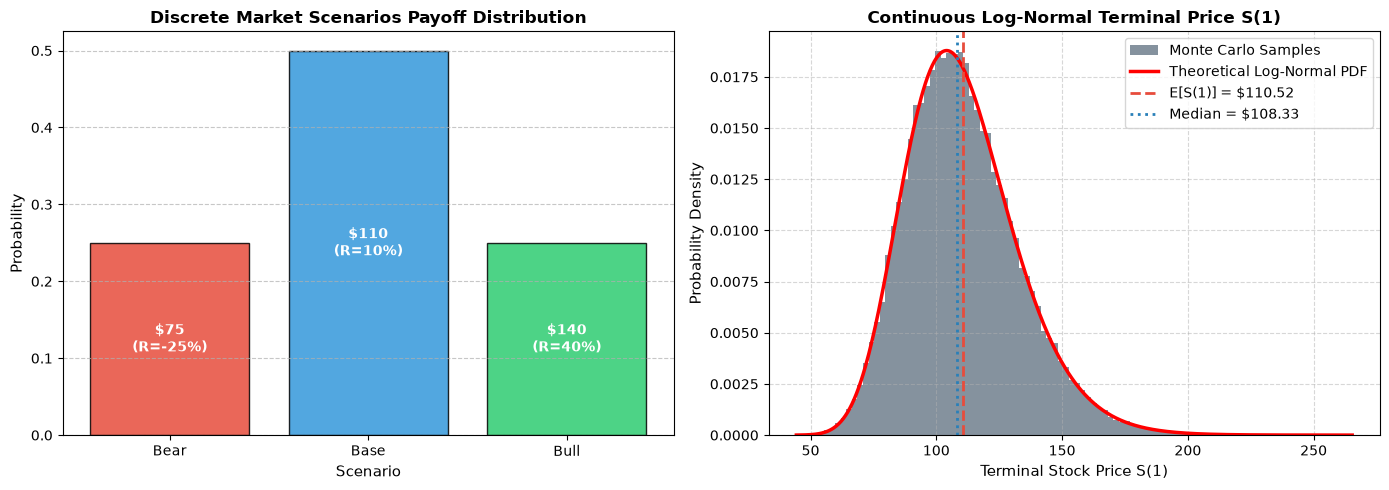

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Set seed for reproducibility
np.random.seed(42)

# --- 1. Discrete Scenario Setup ---
S0 = 100.0  # Initial stock price
R_rf = 0.05  # Risk-free rate (5%)
B0 = 1.0 / (1.0 + R_rf)  # Bond price today

scenarios = ['Bear', 'Base', 'Bull']
probabilities = np.array([0.25, 0.50, 0.25])
S1_discrete = np.array([75.0, 110.0, 140.0])

# Net returns per scenario
returns_discrete = (S1_discrete - S0) / S0

# Expected price and variance
exp_S1_disc = np.sum(S1_discrete * probabilities)
var_S1_disc = np.sum(((S1_discrete - exp_S1_disc) ** 2) * probabilities)
exp_return_disc = (exp_S1_disc - S0) / S0

print(f"=== Discrete Scenario Model ===")
print(f"Initial Price S(0): ${S0:.2f}")
print(f"Discount Factor B(0): {B0:.4f}")
print(f"Expected Terminal Price E[S(1)]: ${exp_S1_disc:.2f}")
print(f"Price Variance Var[S(1)]: {var_S1_disc:.2f}")
print(f"Expected Return E[R]: {exp_return_disc * 100:.2f}%\n")

# --- 2. Continuous Log-Normal Model Setup ---
m_val = 0.08  # Drift parameter
s_val = 0.20  # Volatility parameter
num_simulations = 50000

# Generate standard normal random variables
Z = np.random.normal(0, 1, num_simulations)
S1_continuous = S0 * np.exp(m_val + s_val * Z)

# Theoretical mean and median
theoretical_mean = S0 * np.exp(m_val + (s_val**2) / 2.0)
theoretical_median = S0 * np.exp(m_val)
empirical_mean = np.mean(S1_continuous)

print(f"=== Continuous Log-Normal Model ===")
print(f"Theoretical Expected Price E[S(1)]: ${theoretical_mean:.2f}")
print(f"Theoretical Median Price: ${theoretical_median:.2f}")
print(f"Empirical Mean from Simulation: ${empirical_mean:.2f}")

# --- 3. Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Discrete Scenario Payoff Distribution
axes[0].bar(scenarios, probabilities, color=['#e74c3c', '#3498db', '#2ecc71'], alpha=0.85, edgecolor='black')
axes[0].set_title("Discrete Market Scenarios Payoff Distribution", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Probability", fontsize=11)
axes[0].set_xlabel("Scenario", fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for i, txt in enumerate(S1_discrete):
    axes[0].annotate(f"${txt:.0f}\n(R={returns_discrete[i]*100:.0f}%)", 
                     (scenarios[i], probabilities[i]/2), 
                     ha='center', va='center', color='white', fontweight='bold')

# Plot 2: Continuous Log-Normal Density vs Histogram
count, bins, ignored = axes[1].hist(S1_continuous, bins=100, density=True, alpha=0.6, color='#34495e', label='Monte Carlo Samples')

# Overlay theoretical log-normal PDF
shape = s_val
scale = S0 * np.exp(m_val)
x_pdf = np.linspace(min(S1_continuous), max(S1_continuous), 500)
pdf_fitted = lognorm.pdf(x_pdf, s=shape, scale=scale)

axes[1].plot(x_pdf, pdf_fitted, 'r-', lw=2.5, label='Theoretical Log-Normal PDF')
axes[1].axvline(theoretical_mean, color='#e74c3c', linestyle='--', lw=2, label=f'E[S(1)] = ${theoretical_mean:.2f}')
axes[1].axvline(theoretical_median, color='#2980b9', linestyle=':', lw=2, label=f'Median = ${theoretical_median:.2f}')
axes[1].set_title("Continuous Log-Normal Terminal Price S(1)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Terminal Stock Price S(1)", fontsize=11)
axes[1].set_ylabel("Probability Density", fontsize=11)
axes[1].legend(loc='upper right', frameon=True)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()